# Sycon ciliatum scVelo Analysis

In [1]:
# =============================================================================
# Import Necessary Packages
# =============================================================================

import numpy as np
import os
import scanpy as sc
import anndata as ad
import scvelo as scv

# Additional packages for plotting, logging, etc.
import pandas as pd
import matplotlib.pyplot as plt
import re
import logging
from scipy.stats import median_abs_deviation

/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:

In [2]:
# =============================================================================
# Initialise Environment Settings
# =============================================================================
np.random.seed(12345)  # Set random seed for reproducibility

# Set working directory
working_directory = "/lustre/alice3/data/evassvis/fn76/sycon/sycon_clusterAnnotation/sycon_cluster_analyses/18_scvelo"
os.chdir(working_directory)
print(f"Current working directory: {os.getcwd()}")


Current working directory: /lustre/alice3/data/evassvis/fn76/sycon/sycon_clusterAnnotation/sycon_cluster_analyses/18_scvelo


In [3]:
# Configure Scanpy settings
sc.settings.verbosity = 3
sc.logging.print_header()

scanpy==1.9.8 anndata==0.11.4 umap==0.5.12 numpy==1.26.4 scipy==1.12.0 pandas==2.3.3 scikit-learn==1.7.2 statsmodels==0.14.6 igraph==1.0.0 leidenalg==0.12.0 pynndescent==0.6.0


In [4]:
# Configure scVelo settings
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')

In [5]:
# Cell 1
# import re
# import warnings
# import numpy as np
# import pandas as pd
# import scanpy as sc
# import anndata as ad

pd.set_option("display.max_columns", 200)

def _extract_10x_core(name: str) -> str:
    """
    From Seurat-style names like 'ACGT...-1_3' or 'ACGT...-1',
    return the core 10x barcode 'ACGT...'.
    """
    return re.split(r"-", str(name), maxsplit=1)[0]

def build_loom_style_ids_from_seurat(adata, replicate_col="orig.ident", suffix_char="x"):
    """
    Build LOOM/combined-style IDs: 'S251:ACGT...x'
    using adata.obs[replicate_col] and the core 10x barcode from adata.obs_names.
    """
    if replicate_col not in adata.obs.columns:
        raise KeyError(
            f"'{replicate_col}' not in adata.obs. Available: {list(adata.obs.columns)[:15]}..."
        )
    reps = adata.obs[replicate_col].astype(str).str.strip()
    cores = pd.Index(adata.obs_names).map(_extract_10x_core)
    new_ids = reps + ":" + cores + suffix_char
    return pd.Index(new_ids)

def make_unique(index_like):
    """Ensure uniqueness by appending '#2', '#3', ... to duplicates."""
    idx = pd.Index(index_like)
    if not idx.has_duplicates:
        return idx
    counts, out = {}, []
    for k in idx:
        n = counts.get(k, 0) + 1
        counts[k] = n
        out.append(k if n == 1 else f"{k}#{n}")
    return pd.Index(out)

def overlap_report(idx_a: pd.Index, idx_b: pd.Index, 
                   label_a="A", label_b="B", show=5):
    common  = idx_a.intersection(idx_b)
    only_a  = idx_a.difference(idx_b)
    only_b  = idx_b.difference(idx_a)
    print(f"Total cells in {label_a}: {len(idx_a)}")
    print(f"Total cells in {label_b}: {len(idx_b)}")
    print(f"Number of matching cells: {len(common)}")
    print(f"Cells only in {label_a}: {len(only_a)}")
    print(f"Cells only in {label_b}: {len(only_b)}")
    if show:
        print(f"Examples ({label_a} only):", list(only_a)[:show])
        print(f"Examples ({label_b} only):", list(only_b)[:show])
    return common, only_a, only_b

In [8]:
SEURAT_H5AD = "Sycon_Seuratv4_anndata.h5ad"
COMBINED_H5AD = "1_combined_adata_common.h5ad"  # this is the spliced/unspliced combined file

seurat = sc.read_h5ad(SEURAT_H5AD)
combined = sc.read_h5ad(COMBINED_H5AD)

print(seurat)
# print("Seurat obs columns:", list(seurat.obs.columns))
# print("Seurat var columns:", list(seurat.var.columns))
# print("Seurat obsm keys:", list(seurat.obsm.keys()))

print(combined)
# print("Combined obs columns:", list(combined.obs.columns))
# print("Combined var columns:", list(combined.var.columns))
# print("Combined obsm keys:", list(combined.obsm.keys()))

AnnData object with n_obs × n_vars = 14406 × 12542
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'counts_SCT'
AnnData object with n_obs × n_vars = 14392 × 13846
    obs: 'sample', 'Sycon'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced'


In [9]:
# If combined uses a different suffix than 'x', change suffix_char accordingly.
# (Most velocyto-derived IDs end with 'x')
seurat_new_ids = build_loom_style_ids_from_seurat(
    seurat, replicate_col="orig.ident", suffix_char="x"
)
seurat_new_ids = make_unique(seurat_new_ids)

# Store and rename
seurat.obs["loom_style_id"] = seurat_new_ids
seurat.obs_names = seurat_new_ids

# Confirm format
print("Example new Seurat IDs:", seurat.obs_names[:5].tolist())
print("Example combined IDs:", combined.obs_names[:5].tolist())

Example new Seurat IDs: ['S231:AAACCCAGTATGAAACx', 'S231:AAACGAAAGCGGTATGx', 'S231:AAACGAACAGCATACTx', 'S231:AAACGAAGTTTACCTTx', 'S231:AAACGCTCAAGTTCCAx']
Example combined IDs: ['S251:TCGGGTGTCCGCACGAx', 'S251:GAAGAATAGGTTACAAx', 'S251:CCAATTTAGCTTACGTx', 'S251:ATTCAGGCACAGTCGCx', 'S232:GGTTAACGTCGTCATAx']


In [10]:
comb_idx   = pd.Index(combined.obs_names)
seurat_idx = pd.Index(seurat.obs_names)

common_cells, comb_only, seurat_only = overlap_report(
    comb_idx, seurat_idx, label_a="combined", label_b="seurat", show=5
)

if len(common_cells) == 0:
    warnings.warn(
        "No overlap after ID harmonization. Check 'orig.ident' values (should be like 'S251') "
        "and suffix_char. Print a few names to debug."
    )

Total cells in combined: 14392
Total cells in seurat: 14406
Number of matching cells: 14388
Cells only in combined: 4
Cells only in seurat: 18
Examples (combined only): ['S251:AATGACCAGACCAACGx', 'S251:CATGCGGGTCAGGCAAx', 'S252:CTCACTGCAAAGCAATx', 'S252:GCCCGAAAGTGATGGCx']
Examples (seurat only): ['S231:AAGACAACATGTGCCGx', 'S231:CATGCGGGTCAGGCAAx', 'S231:CCTCATGGTAGAATACx', 'S231:CTAAGTGAGACGACTGx', 'S231:CTCACTGCAAAGCAATx']


In [11]:
# Subset *and order* combined to match Seurat
seurat_common = seurat[common_cells].copy()
combined_common = combined[seurat_common.obs_names].copy()  # same order as seurat_common

print(seurat_common)
print(combined_common)

AnnData object with n_obs × n_vars = 14388 × 12542
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'loom_style_id'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'counts_SCT'
AnnData object with n_obs × n_vars = 14388 × 13846
    obs: 'sample', 'Sycon'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced'


In [12]:
gene_common = pd.Index(combined_common.var_names).intersection(seurat_common.var_names)
if len(gene_common) == 0:
    raise ValueError("No overlapping genes. Check var_names between datasets.")

# Subset both to shared genes in the same order
seurat_common = seurat_common[:, gene_common].copy()
combined_common = combined_common[:, gene_common].copy()

print(f"Common cells: {seurat_common.n_obs}, Common genes: {seurat_common.n_vars}")

Common cells: 14388, Common genes: 12542


In [13]:
adata_merged = seurat_common.copy()  # start with Seurat content

# Copy velocity-related layers from combined (only if present)
for layer_key in ["spliced", "unspliced", "ambiguous", "matrix"]:
    if layer_key in combined_common.layers:
        adata_merged.layers[layer_key] = combined_common.layers[layer_key].copy()

print(adata_merged)
print("Merged layers:", list(adata_merged.layers.keys()))

AnnData object with n_obs × n_vars = 14388 × 12542
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'loom_style_id'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'counts_SCT', 'spliced', 'unspliced', 'ambiguous', 'matrix'
Merged layers: ['counts_SCT', 'spliced', 'unspliced', 'ambiguous', 'matrix']


In [14]:
seurat_common.write("1_adata_seurat_common.h5ad", compression="gzip")
combined_common.write("1_combined_adata_common_subset.h5ad", compression="gzip")
adata_merged.write("1_adata_merged_common.h5ad", compression="gzip")

print("Saved:",
      "1_adata_seurat_common.h5ad,",
      "1_combined_adata_common_subset.h5ad,",
      "1_adata_merged_common.h5ad")

Saved: 1_adata_seurat_common.h5ad, 1_combined_adata_common_subset.h5ad, 1_adata_merged_common.h5ad


In [15]:
# Check cell/gene order identity
assert all(adata_merged.obs_names == seurat_common.obs_names)
assert all(adata_merged.var_names == seurat_common.var_names)

# Check that velocity layers match combined_common shapes
for k in ["spliced", "unspliced"]:
    if k in adata_merged.layers:
        a = adata_merged.layers[k].shape
        b = combined_common.layers[k].shape
        print(k, "shape merged vs combined:", a, b)
        assert a == b

print("All checks passed.")

spliced shape merged vs combined: (14388, 12542) (14388, 12542)
unspliced shape merged vs combined: (14388, 12542) (14388, 12542)
All checks passed.


In [16]:
# =============================================================================
# scVelo Processing
# =============================================================================

In [17]:
# Reload the common AnnData objects
combined_adata_common = ad.read_h5ad("1_combined_adata_common_subset.h5ad")
adata_seurat_common = ad.read_h5ad("1_adata_merged_common.h5ad")

In [18]:
# Merge the data for the subset as done for the full dataset
adata = combined_adata_common.copy()
adata.X = adata_seurat_common.X.copy()
adata.layers = adata_seurat_common.layers.copy()
adata.obs = adata_seurat_common.obs.copy()
adata.var = adata_seurat_common.var.copy()
for key in adata_seurat_common.obsm.keys():
    adata.obsm[key] = adata_seurat_common.obsm[key].copy()
adata.uns = adata_seurat_common.uns.copy()

In [19]:
# Retain spliced/unspliced layers from the original combined loom data for the subset
adata.layers['ambiguous'] = combined_adata_common.layers['ambiguous'].copy()
adata.layers['matrix'] = combined_adata_common.layers['matrix'].copy()
adata.layers['spliced'] = combined_adata_common.layers['spliced'].copy()
adata.layers['unspliced'] = combined_adata_common.layers['unspliced'].copy()

In [20]:
adata.write("1_Velocity_Start_Data_subset.h5ad")

In [21]:
adata = sc.read_h5ad("1_Velocity_Start_Data_subset.h5ad")

In [22]:
adata

AnnData object with n_obs × n_vars = 14388 × 12542
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'loom_style_id'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'ambiguous', 'counts_SCT', 'matrix', 'spliced', 'unspliced'

saving figure to file ./figures/scvelo_proportions_seurat_clusters_proportions.svg


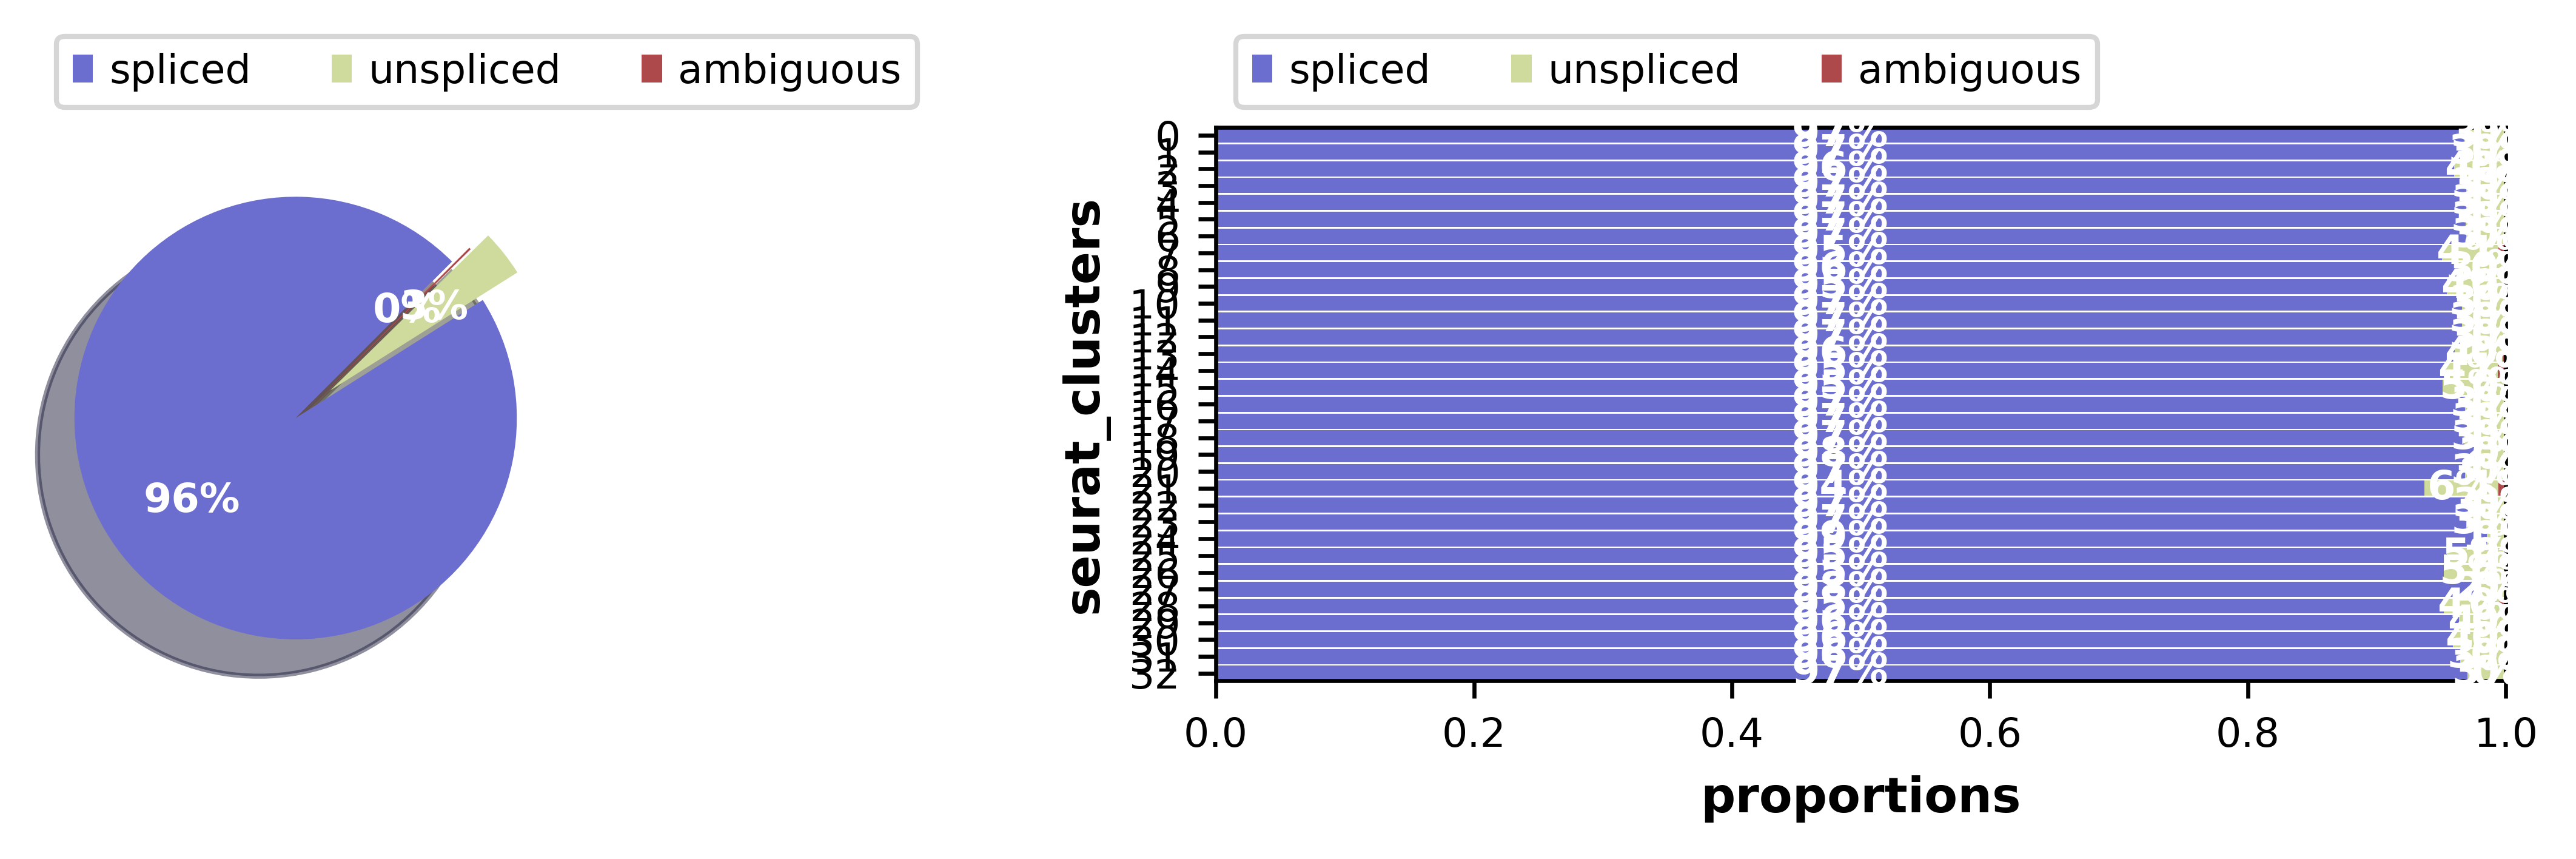

In [23]:
# Plot proportions grouped by seurat_clusters, and save the figure
scv.pl.proportions(adata, groupby="seurat_clusters",
                   save='seurat_clusters_proportions.svg', dpi=300)

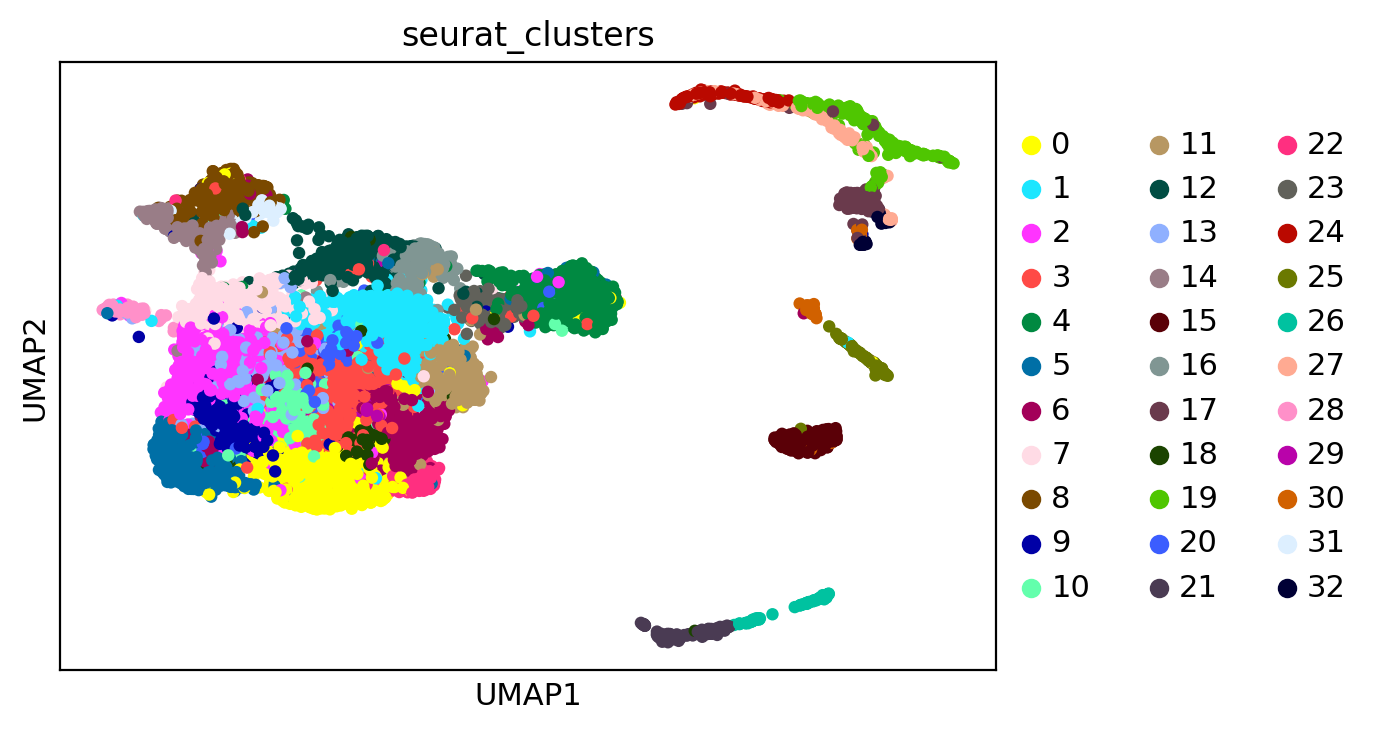

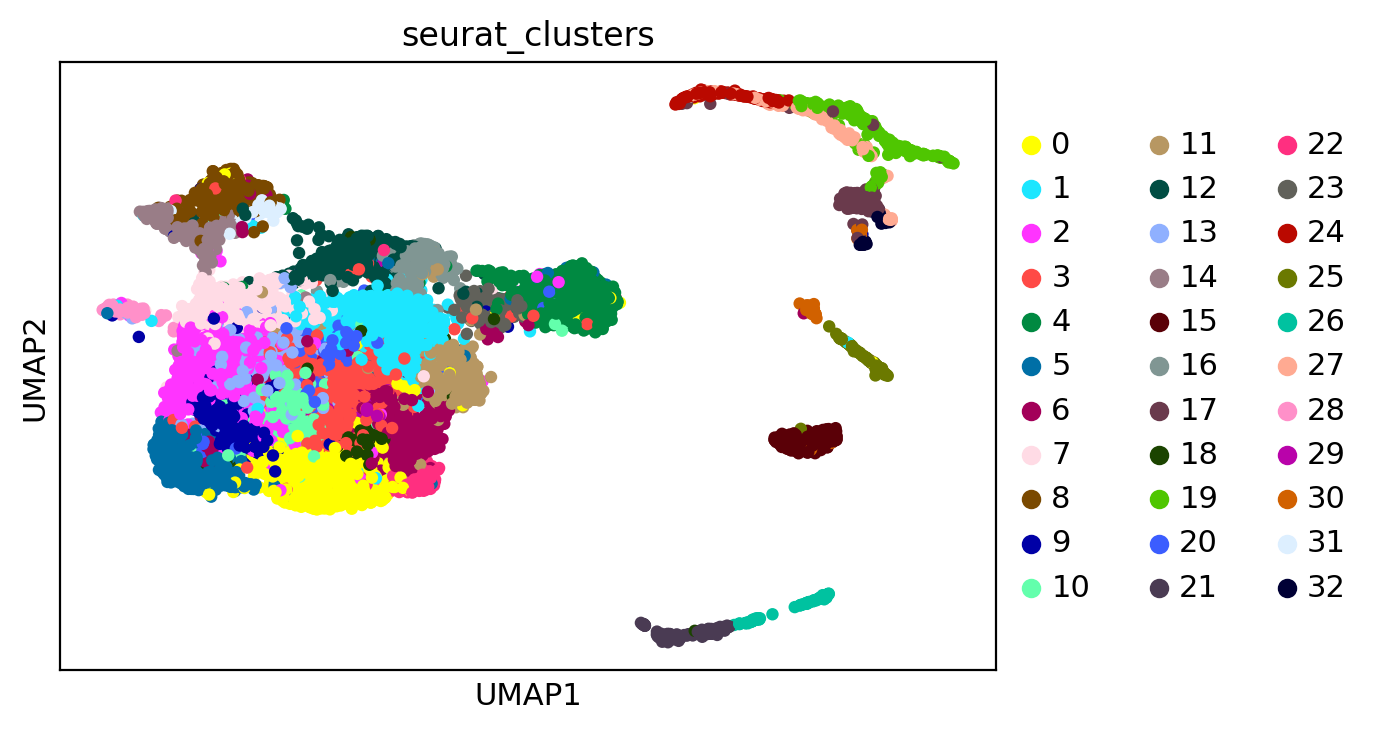

In [24]:
# Example UMAP plot with the custom hex palette
sc.pl.umap(
    adata, 
    color="seurat_clusters", 
    legend_loc='right margin', 
    size=80, 
    save='seurat_clusters.svg'
)
# Example UMAP plot with the custom hex palette
sc.pl.umap(
    adata, 
    color="seurat_clusters", 
    legend_loc='right margin', 
    size=80, 
    save='seurat_clusters.pdf'
)

In [25]:
# Step 1: filter and normalize (no n_top_genes here anymore)
scv.pp.filter_and_normalize(adata, min_shared_counts = 3)

# Step 2: select highly variable genes separately
sc.pp.highly_variable_genes(adata, n_top_genes = 10000)

Filtered out 9329 genes that are detected 3 counts (shared).
Normalized count data: spliced, unspliced.
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [ ]:
# Compute neighbors and moments
sc.pp.neighbors(adata, n_pcs = 100, n_neighbors = 30, random_state = 0)
scv.pp.moments(adata, n_pcs = 100, n_neighbors = 30)

computing neighbors
    using 'X_pca' with n_pcs = 100
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
computing moments based on connectivities
    finished (0:00:13) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [27]:
adata.write("2_Velocity_Processing_subset.h5ad")

In [ ]:
adata = sc.read_h5ad("2_Velocity_Processing_subset.h5ad")

: 

In [ ]:
scv.tl.recover_dynamics(adata, n_jobs=40, show_progress_bar=True)

recovering dynamics (using 40/64 cores)


  0%|          | 0/798 [00:00<?, ?gene/s]

/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/anndata/utils.py:43

In [ ]:
scv.tl.velocity(adata, mode='dynamical')

computing velocities
    finished (0:02:13) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [ ]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/64 cores)


  0%|          | 0/14388 [00:00<?, ?cells/s]

    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [ ]:
adata.write("3_Velocity_scVelo_Dynamical_subset.h5ad")

In [ ]:
# Load AnnData
adata = sc.read_h5ad("3_Velocity_scVelo_Dynamical_subset.h5ad")

computing velocity embedding
    finished (0:00:04) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_seurat_clusters.svg


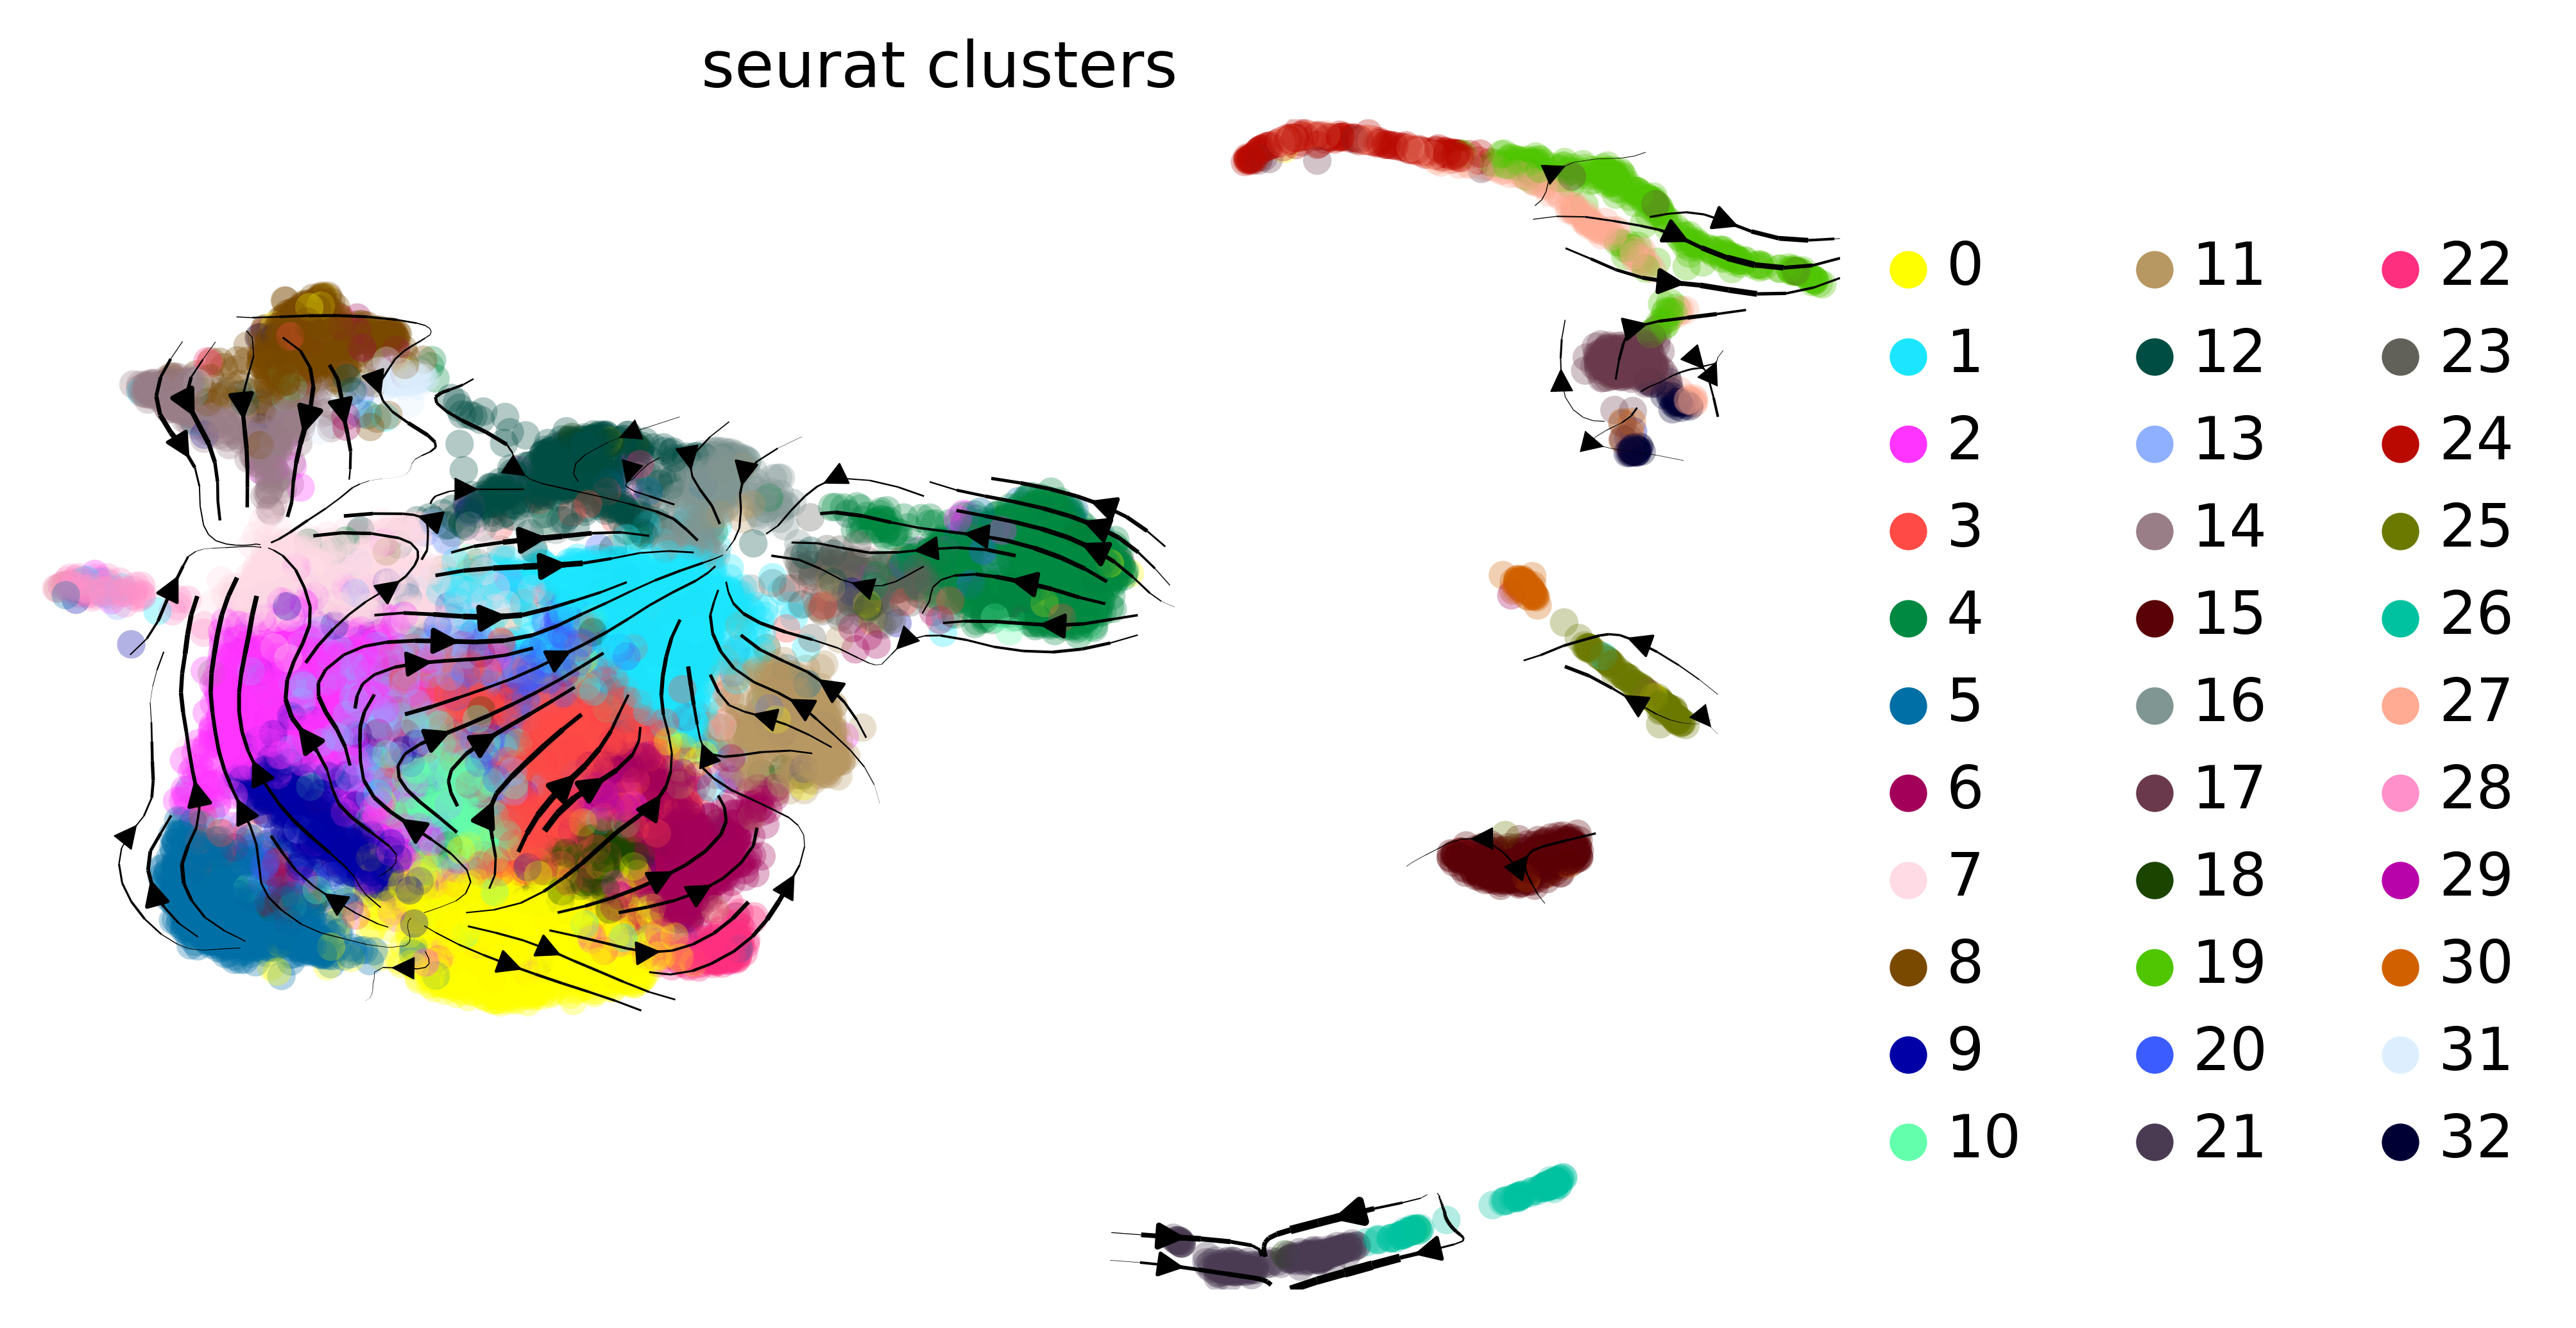

figure cannot be saved as pdf, using png instead (can only output finite numbers in pdf).
saving figure to file ./figures/scvelo_seurat_clusters.png


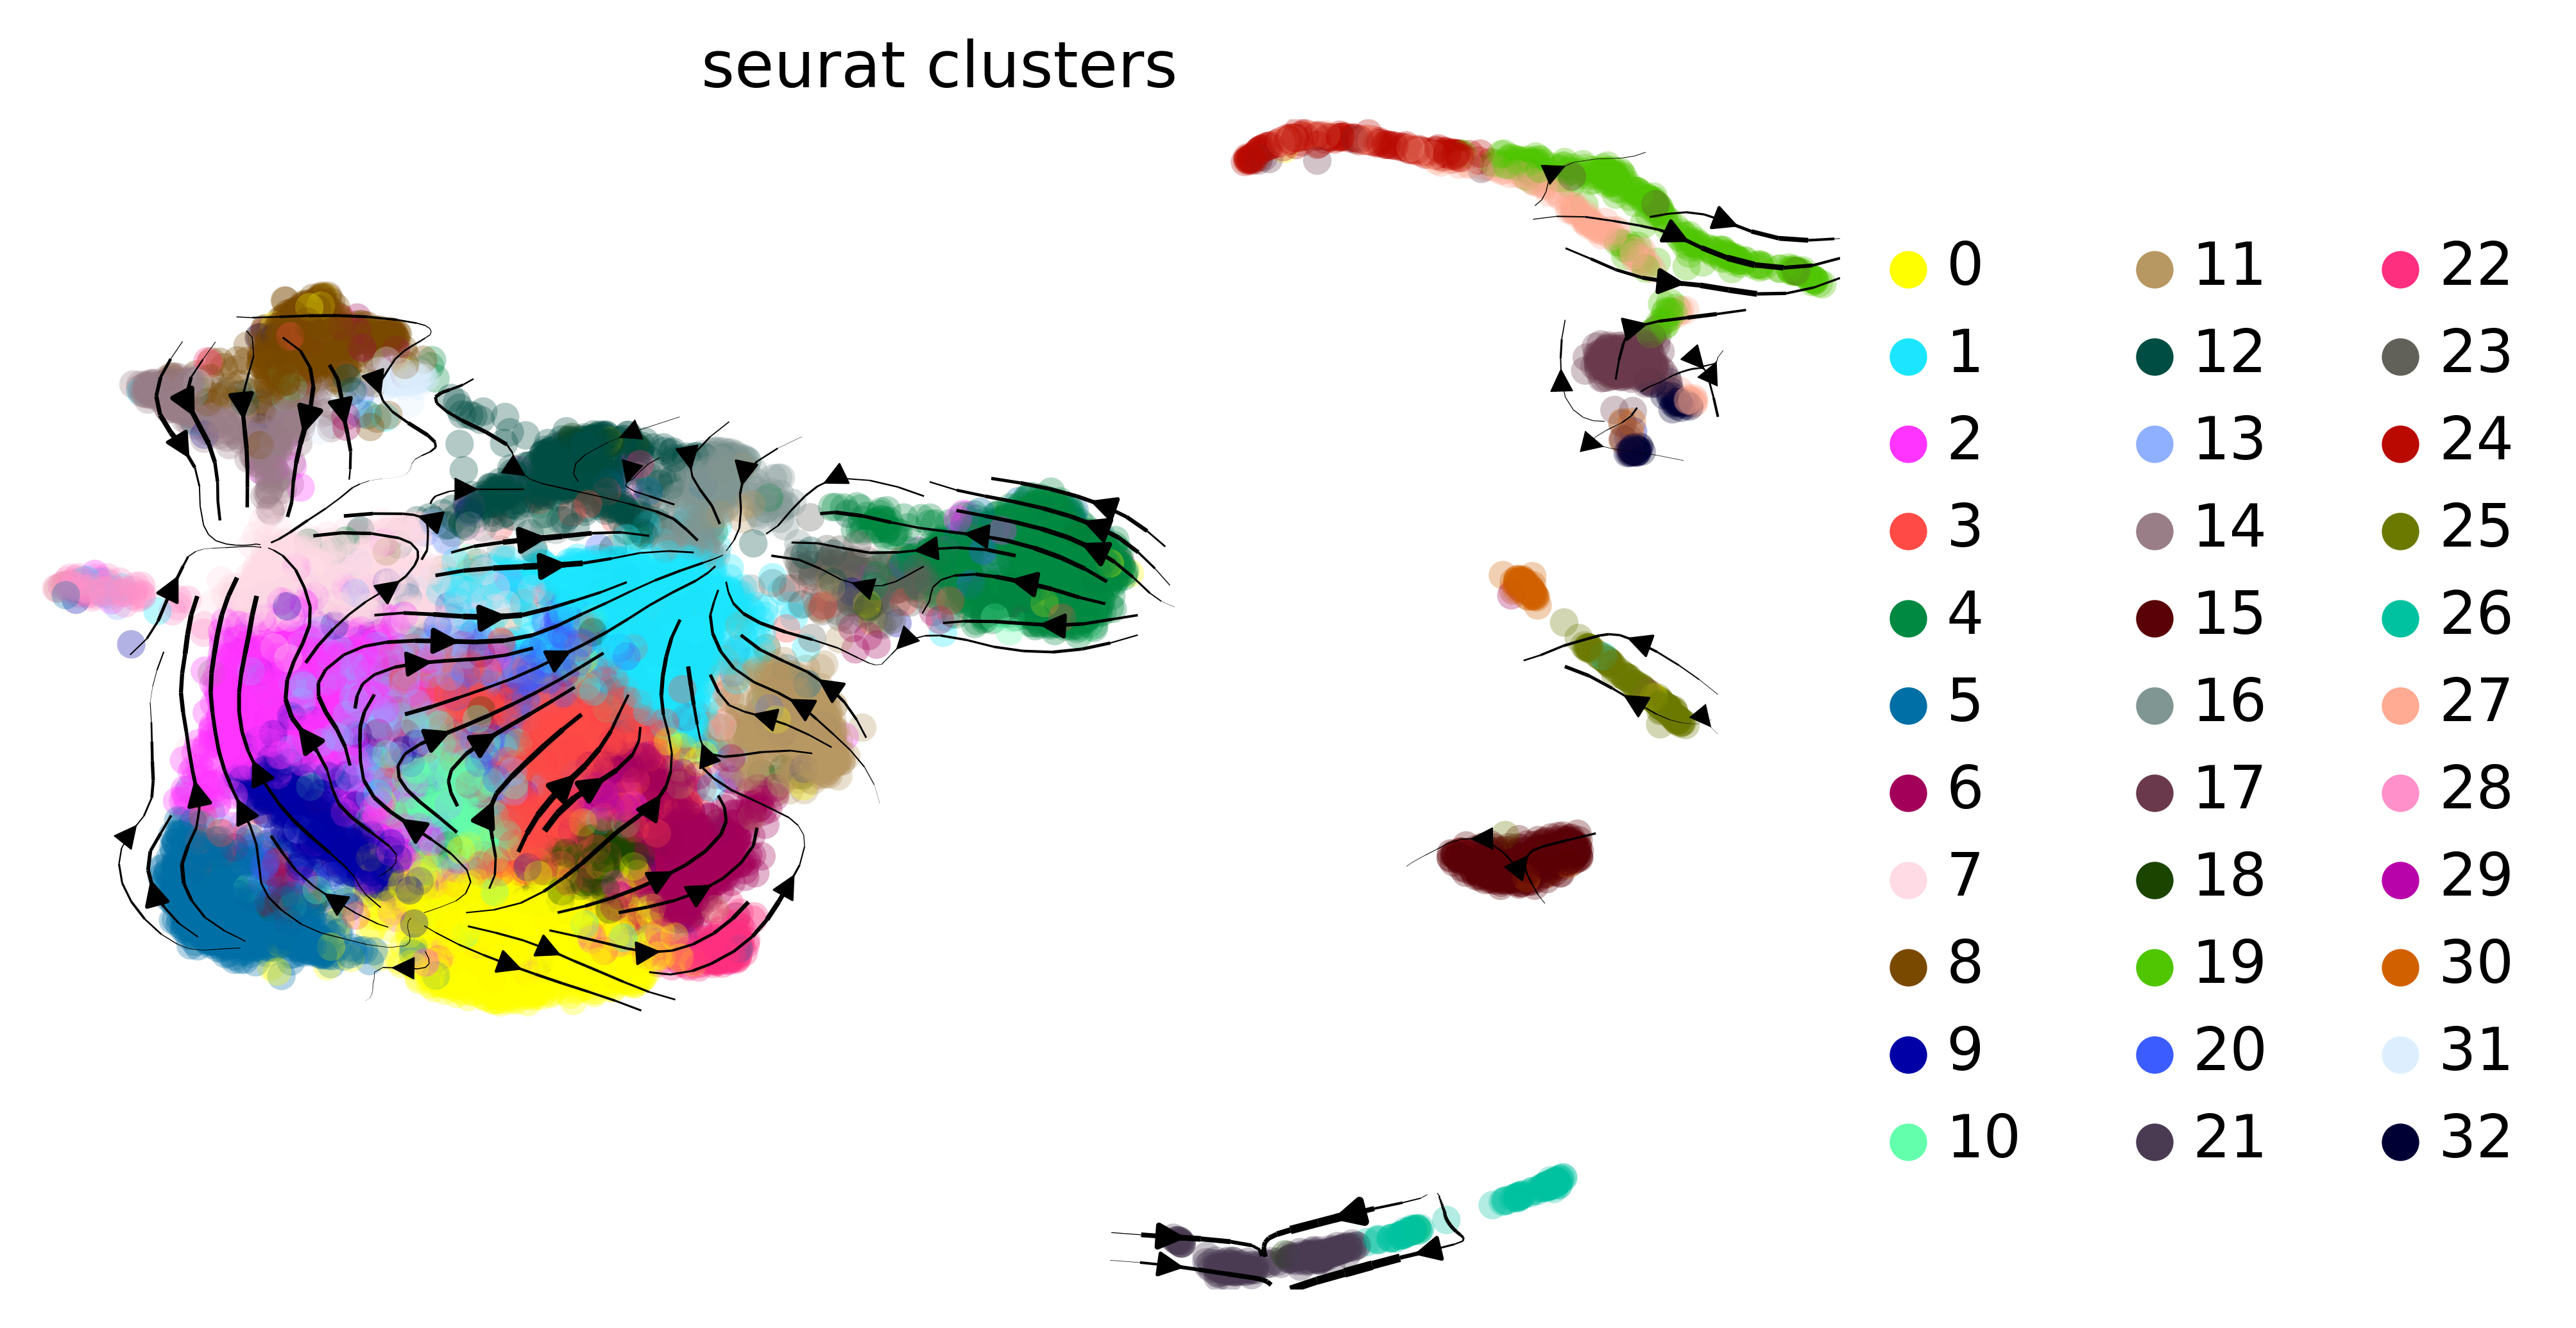

In [ ]:
# ------------------------------------------------------------------------------
# Velocity embedding stream by 'seurat_clusters' with custom colors
scv.pl.velocity_embedding_stream(
    adata, 
    basis='X_umap', 
    color='seurat_clusters', 
    dpi=300, 
    save="seurat_clusters.svg", 
    legend_loc='right margin'
)
# ------------------------------------------------------------------------------
# Velocity embedding stream by 'seurat_clusters' with custom colors
scv.pl.velocity_embedding_stream(
    adata, 
    basis='X_umap', 
    color='seurat_clusters', 
    dpi=300, 
    save="seurat_clusters.pdf", 
    legend_loc='right margin'
)

In [ ]:
# ------------------------------------------------------------------------------
# 4. Create histograms for fit parameters (transcription, splicing, degradation rates)
df = adata.var.copy()
df = df[(df['fit_likelihood'] > 0.1) & (df['velocity_genes'] == True)]

/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/matplotlib/_mathtext.py:1832: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/matplotlib/_mathtext.py:1834: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/matplotlib/_mathtext.py:1842: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_

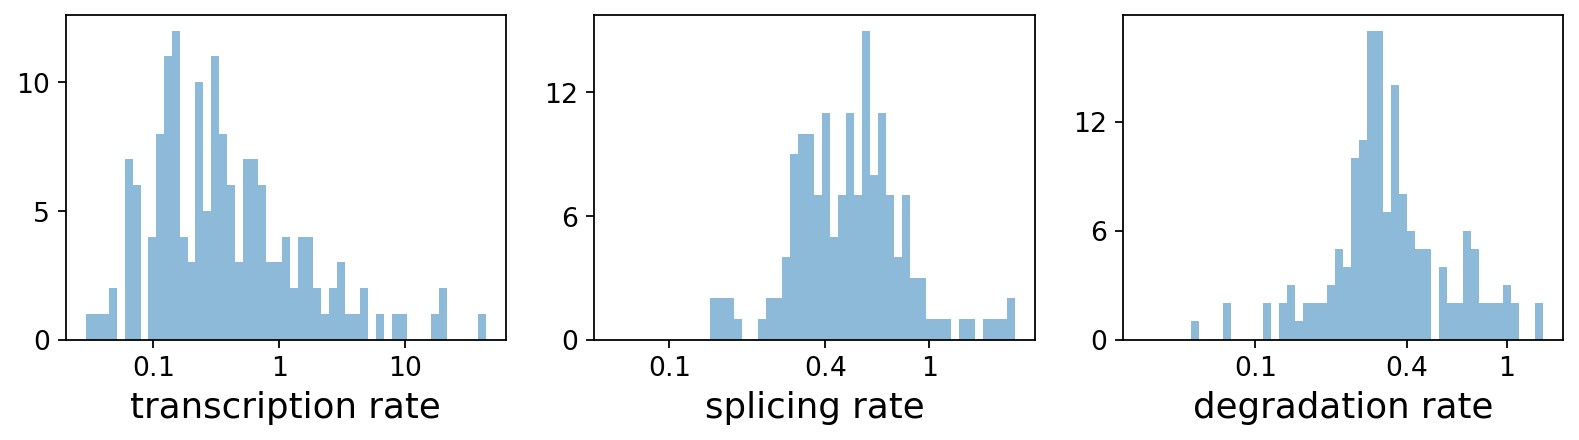

In [ ]:
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[0.1, 0.4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[0.1, 0.4, 1], **kwargs)

In [ ]:
# Optionally, print head of all fit parameters
print(scv.get_df(adata, 'fit*', dropna=True).head())

        fit_r2  fit_alpha   fit_beta  fit_gamma     fit_t_  fit_scaling  \
g49   0.773886   0.561371   2.180255   1.084083   2.728022     0.286189   
g120  0.088830   0.713276  12.319593   0.711081   2.166405     0.046577   
g147  0.279873   0.310957   3.088568   0.389491   3.625104     0.177572   
g151  0.388855   0.555470   2.920836   0.236085  14.711389     0.138795   
g271  0.550101   0.046427   0.022611   0.233612   5.115795    25.349467   

      fit_std_u  fit_std_s  fit_likelihood  fit_u0  fit_s0  fit_pval_steady  \
g49    0.069448   0.112840    3.292994e-02     0.0     0.0         0.110039   
g120   0.012688   0.143012    1.770172e-01     0.0     0.0         0.380680   
g147   0.023901   0.162263    2.796898e-08     0.0     0.0         0.410232   
g151   0.062533   0.446039    9.342152e-02     0.0     0.0         0.494453   
g271   0.785247   0.032526    9.844662e-10     0.0     0.0         0.032437   

      fit_steady_u  fit_steady_s  fit_variance  fit_alignment_scaling  
g4

/local/fn76/ipykernel_993233/464970876.py:2: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  print(scv.get_df(adata, 'fit*', dropna=True).head())


In [ ]:
scv.tl.latent_time(adata)

computing terminal states
    identified 5 regions of root cells and 5 regions of end points .
    finished (0:00:02) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:32) --> added 
    'latent_time', shared time (adata.obs)


saving figure to file ./figures/scvelo_latent_time.svg


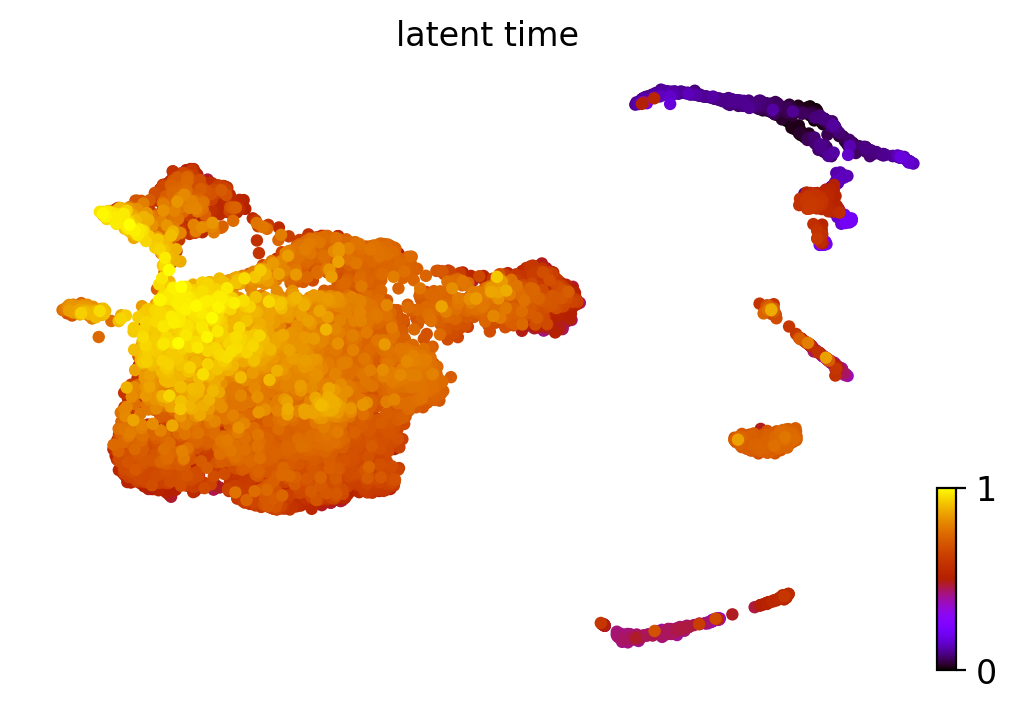

saving figure to file ./figures/scvelo_latent_time.pdf


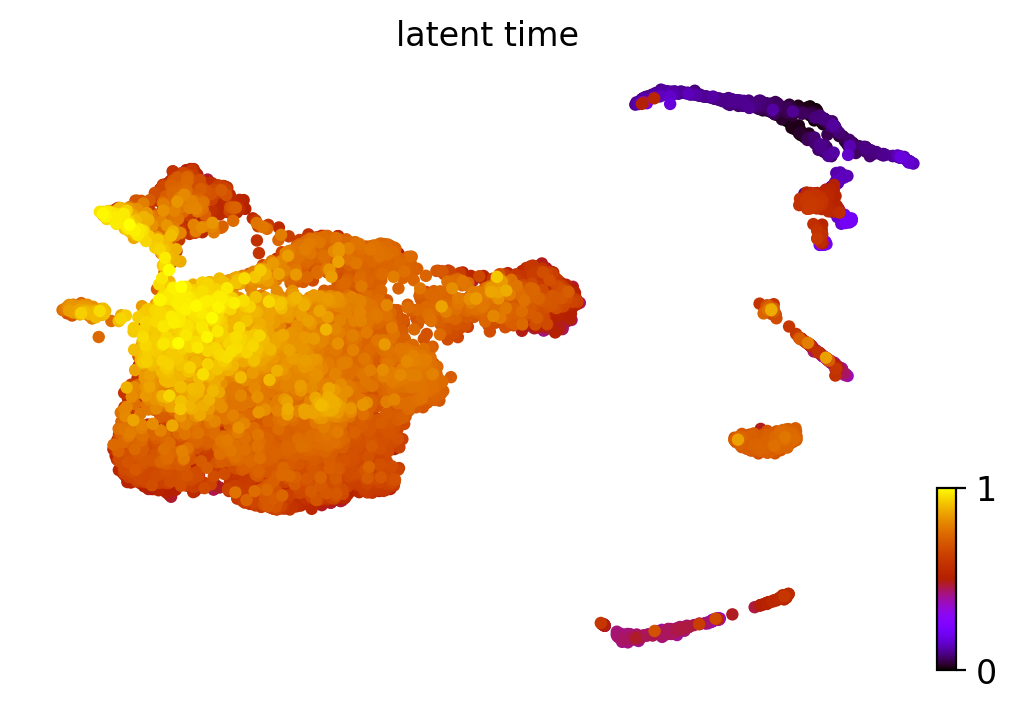

In [ ]:
scv.pl.scatter(
    adata, color="latent_time", color_map="gnuplot", size=80, save="latent_time.svg"
)
scv.pl.scatter(
    adata, color="latent_time", color_map="gnuplot", size=80, save="latent_time.pdf"
)


In [ ]:
# ------------------------------------------------------------------------------
# 6. Top 500 genes based on fit_likelihood and heatmap
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index[:500]

In [ ]:
# GO for top dynamical genes (for R GO analysis)
import numpy as np
import pandas as pd

# 1) choose the “dynamical” genes and the background
dyn_genes = adata.var_names[adata.var['fit_likelihood'] > 0.1]   # tweak threshold
background = adata.var_names[~adata.var['fit_likelihood'].isna()]  # all tested

# 2) assign each dynamical gene a latent-time “peak”
lt = adata.obs['latent_time'].values
def gene_peak_time(g):
    # use expression layer you trust ("X", "spliced", "Ms", etc.)
    x = adata[:, g].layers.get("spliced", adata[:, g].X).A.ravel() if hasattr(adata[:, g].X, "A") else np.array(adata[:, g].X).ravel()
    return lt[np.argmax(x)]

peaks = {g: gene_peak_time(g) for g in dyn_genes}

# 3) bin genes by peak latent time
k = 20  # number of bins
quantiles = pd.qcut(pd.Series(peaks), q=k, labels=False, duplicates='drop')

# 5) write per-bin gene lists + background as plain text
bins = []
for b in sorted(quantiles.unique()):
    genes_in_bin = [g for g, bb in quantiles.items() if bb == b]
    bins.append((b, genes_in_bin))
    with open(f"genes_bin_{b}.txt", "w") as fh:
        fh.write("\n".join(genes_in_bin))

with open("genes_background.txt", "w") as fh:
    fh.write("\n".join(background))

In [ ]:
dyn_genes = adata.var_names[adata.var['fit_likelihood'] > 0.1]  # example threshold
print(len(dyn_genes))
import numpy as np
import pandas as pd

gene_peak_time = {}
for gene in dyn_genes:
    expr = adata[:, gene].layers["spliced"].toarray().flatten()  # or "X"
    lt = adata.obs['latent_time'].values
    peak_time = lt[np.argmax(expr)]
    gene_peak_time[gene] = peak_time

gene_peak_df = pd.DataFrame.from_dict(gene_peak_time, orient='index', columns=['peak_latent_time'])

199


In [ ]:
# Example: split into 20 equal bins
gene_peak_df['bin'] = pd.qcut(gene_peak_df['peak_latent_time'], q=20, labels=False)

In [ ]:
# adata = sc.read_h5ad("4_Velocity_scVelo_processed_subset.h5ad")

In [10]:
help(scv.pl.heatmap)

Help on function heatmap in module scvelo.plotting.heatmap:

heatmap(adata, var_names, sortby='latent_time', layer='Ms', color_map='viridis', col_color=None, palette='viridis', n_convolve=30, standard_scale=0, sort=True, colorbar=None, col_cluster=False, row_cluster=False, context=None, font_scale=None, figsize=(8, 4), show=None, save=None, **kwargs)
    Plot time series for genes as heatmap.
    
    Parameters
    ----------
    adata: :class:`~anndata.AnnData`
        Annotated data matrix.
    var_names: `str`,  list of `str`
        Names of variables to use for the plot.
    sortby: `str` (default: `'latent_time'`)
        Observation key to extract time data from.
    layer: `str` (default: `'Ms'`)
        Layer key to extract count data from.
    color_map: `str` (default: `'viridis'`)
        String denoting matplotlib color map.
    col_color: `str` or list of `str` (default: `None`)
        String denoting matplotlib color map to use along the columns.
    palette: list of `

saving figure to file ./figures/scvelo_heatmap__dynamicalgenes500_seurat_clusters.png


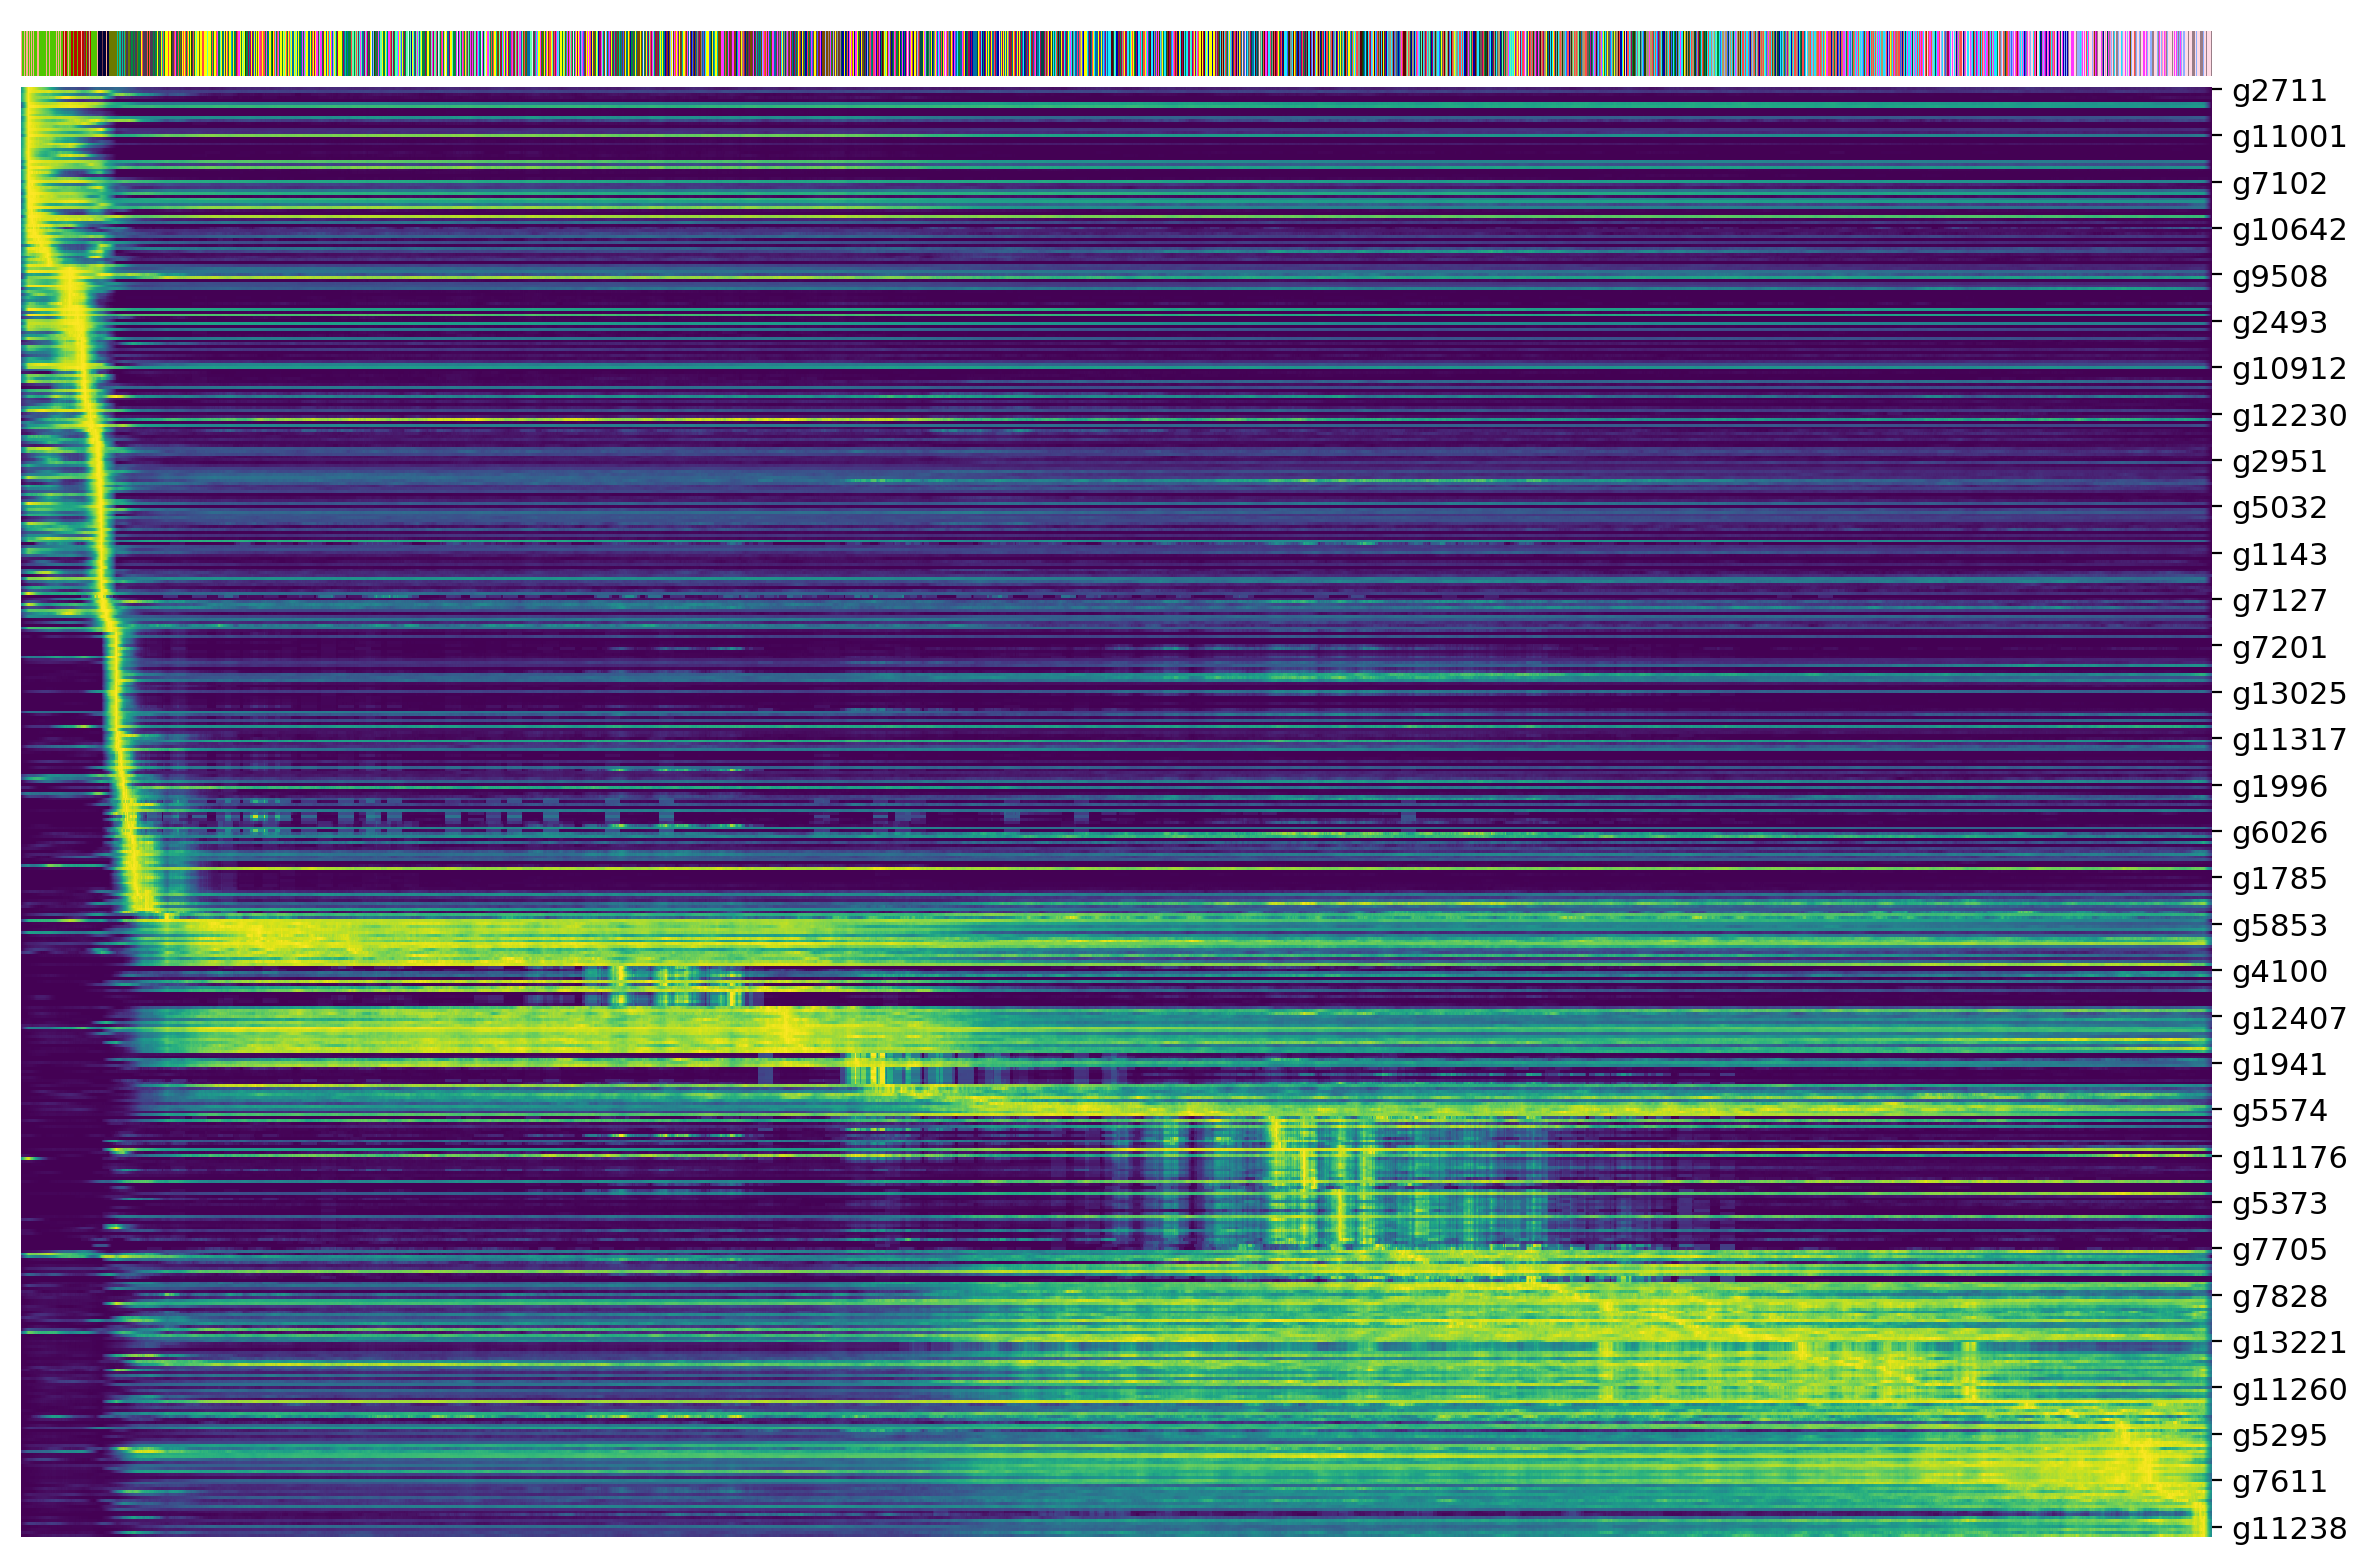

In [9]:
# Generate a heatmap of the top genes, sorted by latent time.
scv.pl.heatmap(
    adata, 
    var_names = top_genes, 
    sortby='latent_time',
    col_color='seurat_clusters',  # set the column color annotation to neuronal_annotation_fine
    n_convolve=100,  
    save='_dynamicalgenes500_seurat_clusters.png',
figsize=(12, 8)
)

In [45]:
# ------------------------------------------------------------------------------
# 7. Rank dynamical genes by 'seurat_clusters'
scv.tl.rank_dynamical_genes(adata, groupby='seurat_clusters')
ranked_df = scv.get_df(adata, 'rank_dynamical_genes/names')
print(ranked_df.head(5))

# Save the ranked dynamical genes DataFrame to CSV
ranked_df.to_csv("ranked_dynamical_genes.csv", index=False)

ranking genes by cluster-specific likelihoods
    finished (0:01:10) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)
        0      1       2       3       4       5       6      7       8  \
0   g3861  g3861  g13344   g3861  g13344  g13344   g3861  g6134  g13344   
1   g3242  g3242   g6134   g1421   g3861   g6134    g898  g3861   g2025   
2   g6134  g8427   g3242  g10622    g898   g3242   g3242  g3242   g3861   
3  g10622  g1960   g3861    g898  g10622    g898  g10622  g8427   g6134   
4   g7102  g7611    g898   g6134   g5900   g5900   g1960  g6171    g898   

        9      10     11      12      13      14      15     16     17     18  \
0  g13344  g13344  g3861  g13344  g13344  g13344   g6541  g3242  g8313  g7830   
1   g6134   g6134  g3242   g3861   g3861   g3861  g11677  g1960  g6317  g1421   
2    g898   g3242  g6134   g3242   g6134   g6171   g3337  g7611   g898  g3242   
3   g3242   g5900  g7611   g1960    g898   g3242   g7260  g1421  g1960  g3861 

/local/fn76/ipykernel_993233/651001687.py:4: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  ranked_df = scv.get_df(adata, 'rank_dynamical_genes/names')


In [46]:
# -------------------------------------------------------------------------------
# 9. Rank velocity genes grouped by 'seurat_clusters'
scv.tl.rank_velocity_genes(adata, groupby='seurat_clusters', min_corr=0.3)
# Create a DataFrame from the gene names ranked for each group
df = pd.DataFrame(adata.uns['rank_velocity_genes']['names'])
# Save the ranked velocity genes to a CSV file
df.to_csv('top_velocity_genes_seurat_clusters.csv', index=False)

ranking velocity genes


/home/f/fn76/miniforge3/envs/scvelo_env/lib/python3.10/site-packages/scvelo/tools/utils.py:463: DeprecationWarning: Please import `rankdata` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import rankdata


    finished (0:00:39) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
saving figure to file ./figures/scvelo_velocity_length_and_confidence.svg


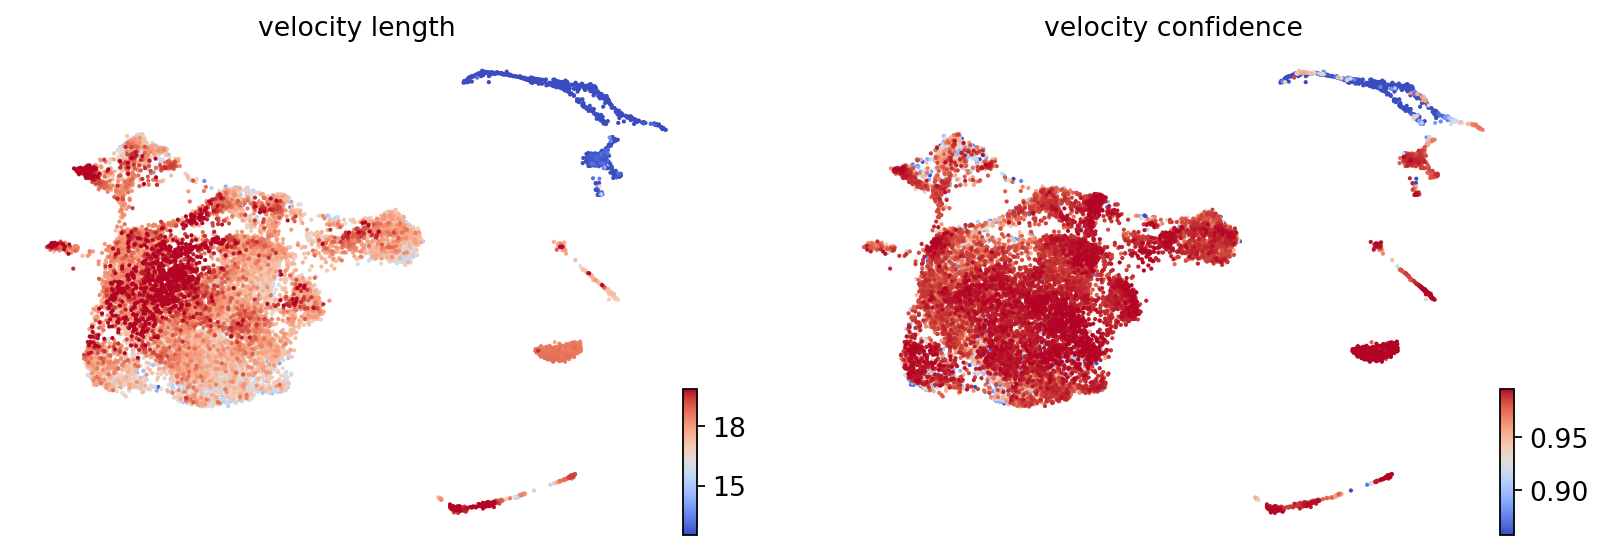

saving figure to file ./figures/scvelo_velocity_length_and_confidence.pdf


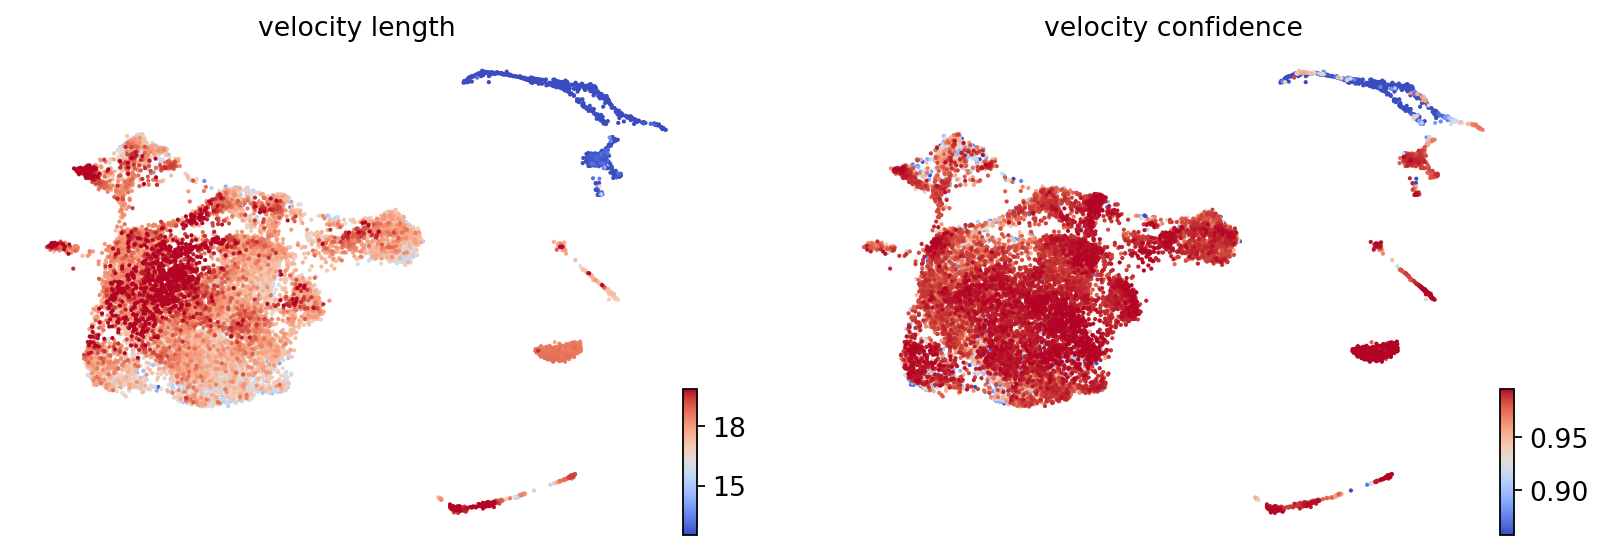

In [47]:
# -------------------------------------------------------------------------------
# 10. Calculate velocity confidence and plot scatter of velocity length and confidence
scv.tl.velocity_confidence(adata)
keys = ('velocity_length', 'velocity_confidence')
scv.pl.scatter(
    adata, 
    c=keys, 
    cmap='coolwarm', 
    perc=[5, 95], 
    dpi=300, 
    save='velocity_length_and_confidence.svg'
)
scv.pl.scatter(
    adata, 
    c=keys, 
    cmap='coolwarm', 
    perc=[5, 95], 
    dpi=300, 
    save='velocity_length_and_confidence.pdf'
)

saving figure to file ./figures/scvelo_velocity_pseudotime.svg


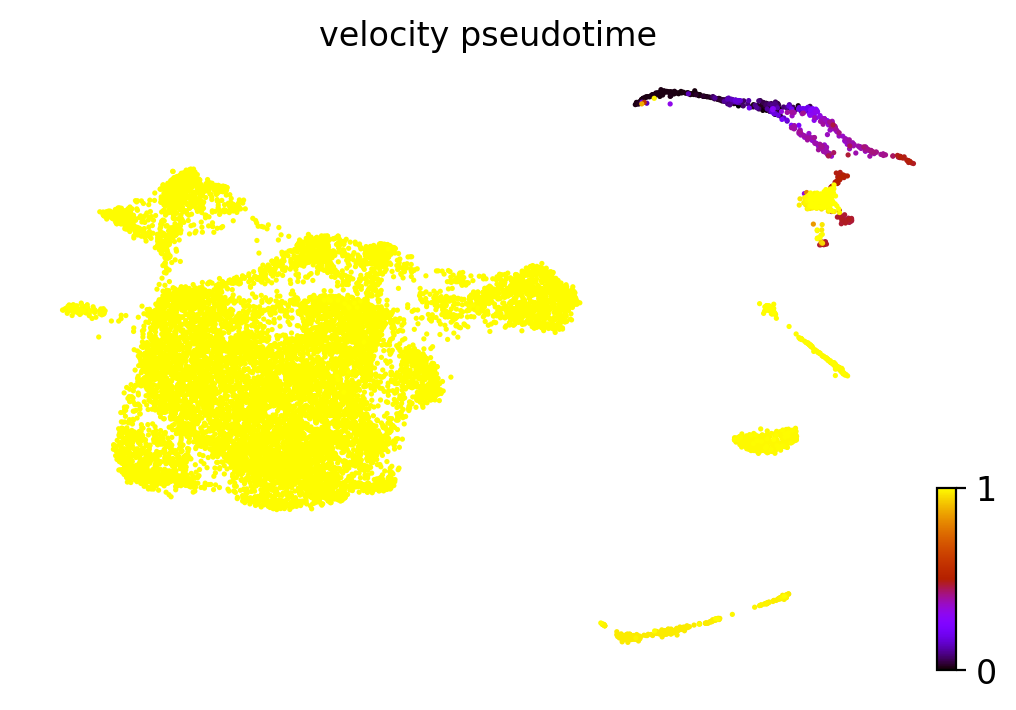

saving figure to file ./figures/scvelo_velocity_pseudotime.pdf


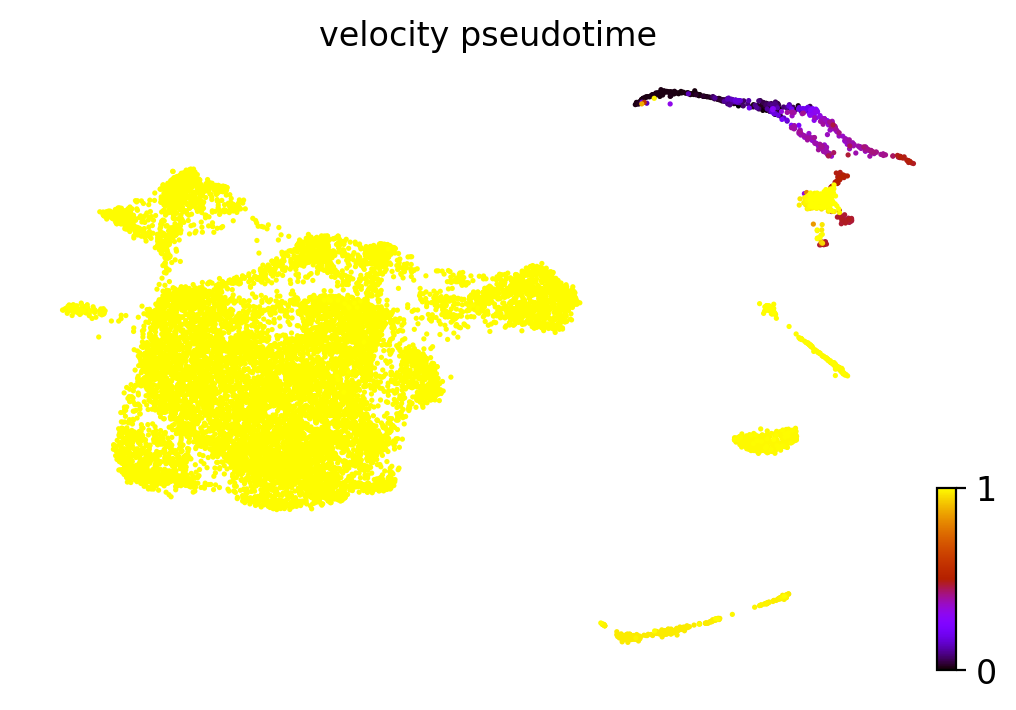

In [48]:
# -------------------------------------------------------------------------------
# 12. Compute velocity pseudotime and plot scatter colored by pseudotime
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(
    adata, 
    color='velocity_pseudotime', 
    cmap='gnuplot', 
    save='velocity_pseudotime.svg'
)
scv.pl.scatter(
    adata, 
    color='velocity_pseudotime', 
    cmap='gnuplot', 
    save='velocity_pseudotime.pdf'
)

In [49]:
adata.write("4_Velocity_scVelo_processed_subset.h5ad")

In [50]:
adata

AnnData object with n_obs × n_vars = 14388 × 3213
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'loom_style_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes', 'spearmans_score', 'velocity_score'
    uns: 'hvg', 'neighbors', 'recover_dynamics', 'seurat_clusters_colors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'rank_dynamical_genes', 'rank_velocity_genes'
    obsm: 'X_harmony'

In [52]:
help(scv.pl.velocity_embedding_stream)

Help on function velocity_embedding_stream in module scvelo.plotting.velocity_embedding_stream:

velocity_embedding_stream(adata, basis=None, vkey='velocity', density=2, smooth=None, min_mass=None, cutoff_perc=None, arrow_color=None, arrow_size=1, arrow_style='-|>', max_length=4, integration_direction='both', linewidth=None, n_neighbors=None, recompute=None, color=None, use_raw=None, layer=None, color_map=None, colorbar=True, palette=None, size=None, alpha=0.3, perc=None, X=None, V=None, X_grid=None, V_grid=None, sort_order=True, groups=None, components=None, legend_loc='on data', legend_fontsize=None, legend_fontweight=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, dpi=None, frameon=None, show=None, save=None, ax=None, ncols=None, **kwargs)
    Stream plot of velocities on the embedding.
    
        Parameters
        ----------
        adata: :class:`~anndata.AnnData`
            Annotated data matrix.
        density: `float` (default: 2)
            Contr